#Ass14  boston housing
# Linear Regression Model for House Price Prediction
# Dataset Used: California Housing Dataset

In [ ]:
# Step 1: Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
# Step 2: Load dataset
cal_housing = fetch_california_housing()

# Step 3: Create DataFrame
data = pd.DataFrame(cal_housing.data, columns=cal_housing.feature_names)
data['Price'] = cal_housing.target

# Display first 5 rows
print("Dataset Preview:\n")
print(data.head())

# Step 4: Define input (X) and output (y)
X = data.drop('Price', axis=1)
y = data['Price']

# Step 5: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)


Dataset Preview:

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  Price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  



Actual vs Predicted Prices:

       Actual  Predicted
14740   1.369   2.281107
10101   2.413   2.790091
20566   2.007   1.903328
2670    0.725   1.017603
15709   4.600   2.948524
439     1.200   2.090540
845     2.470   2.991239
3768    3.369   3.056619
964     3.397   2.980227
8681    2.656   2.388060

Model Performance:
Mean Squared Error (MSE): 0.5289841670367208
R2 Score: 0.5943232652466204


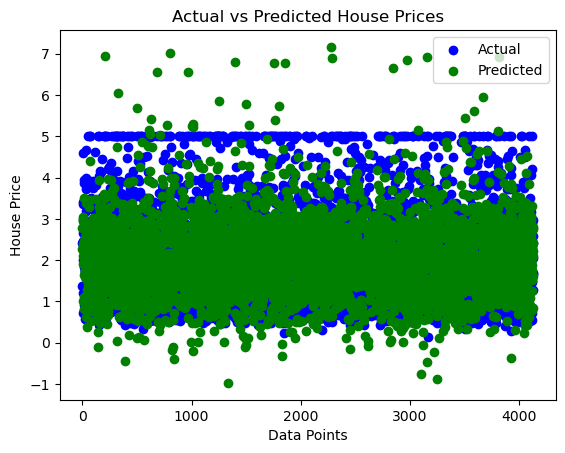

In [8]:
# Step 6: Train Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 7: Predict prices
y_pred = model.predict(X_test)

# Step 8: Compare Actual vs Predicted
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print("\nActual vs Predicted Prices:\n")
print(result.head(10))

# Step 9: Model Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)

# Step 10: Plot Actual vs Predicted Prices
plt.scatter(range(len(y_test)), y_test, color='blue', label='Actual')
plt.scatter(range(len(y_pred)), y_pred, color='green', label='Predicted')
plt.xlabel("Data Points")
plt.ylabel("House Price")
plt.title("Actual vs Predicted House Prices")
plt.legend()
plt.show()